# Notebook 4 — Bubble Diagnostics

This notebook computes the bubble existence conditions from **Theorem 1** and **Corollary 1** of `Corollary_V3.tex`:

1. **Leakage ratio** $a_t$ (proof of Theorem 1, lines 688–698)
2. **Corollary 1 primitive conditions**:
   - (2a): $\sum D_t^u / e_{US,t}^u < \infty$
   - (2b): $\sum (C_t^b / C_t^u)^{1-\gamma} < \infty$
3. **Fundamental value** decomposition: $Q_{US,t} = V_t + B_t$
4. Four-panel diagnostic plots

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Stock_bubble_framework/Agentic_coding`


Plots.GRBackend()

In [2]:
# ── Run the full simulation ──
result = run_simulation(ModelParams(); verbose=true);

Generating exogenous paths...
Solving balanced-growth states...
  t= 20: ω_b=0.5204  θ_b=-1.126906  R_f_b=1.1172
  t= 40: ω_b=0.6698  θ_b=-0.800602  R_f_b=1.1048
  t= 60: ω_b=0.7567  θ_b=-0.674657  R_f_b=1.1035
  t= 80: ω_b=0.7881  θ_b=-0.633330  R_f_b=1.1038
  t=100: ω_b=0.7970  θ_b=-0.621875  R_f_b=1.1040
  t=120: ω_b=0.7993  θ_b=-0.618970  R_f_b=1.1041
Solving u-path by backward induction...
  t=110: ω=0.1360  θ=-0.618189  θ*_US=+1714.1542  R_f=1.1876  q_US=0.066262  ‖F‖=8.3e-13
  t=100: ω=0.1612  θ=-0.618578  θ*_US=+826.6352  R_f=1.1876  q_US=0.077287  ‖F‖=3.2e-13
  t= 90: ω=0.1922  θ=-0.619496  θ*_US=+398.9784  R_f=1.1875  q_US=0.089488  ‖F‖=1.9e-13
  t= 80: ω=0.2313  θ=-0.621955  θ*_US=+193.0458  R_f=1.1874  q_US=0.102758  ‖F‖=5.8e-14
  t= 70: ω=0.2817  θ=-0.628646  θ*_US=+94.0370  R_f=1.1871  q_US=0.116997  ‖F‖=3.0e-15
  t= 60: ω=0.3432  θ=-0.646471  θ*_US=+46.6051  R_f=1.1865  q_US=0.132268  ‖F‖=2.2e-15
  t= 50: ω=0.4051  θ=-0.688323  θ*_US=+23.9148  R_f=1.1855  q_US=0.149289  

In [11]:
p    = result.params
diag = result.diagnostics
u_path = result.u_path
paths  = result.paths
bs     = result.balanced_states
T = p.T_max
tt = 1:T

# Pre-compute Q vectors for later use
Q_US_vec = [u_path[t].Q_US for t in tt]
Q_W_vec  = [u_path[t].Q_W  for t in tt];

## 1. Corollary 1 — Primitive Conditions

### Condition (2a): $\sum_{t=1}^\infty D_t^u / e_{US,t}^u < \infty$

This is a geometric series with ratio $g_{D,u}/g_{e,u}$. It converges whenever $g_{D,u} < g_{e,u}$ (dividends grow slower than endowments in state $u$).

### Condition (2b): $\sum_{t=1}^\infty (C_t^b / C_t^u)^{1-\gamma} < \infty$

Since $C_t^z = A_{t-1} R_{A,t}^z$, this simplifies to $(R_{A,t}^b / R_{A,t}^u)^{1-\gamma}$.

In [12]:
println("══ Corollary 1 Results ══")
@printf("  Condition (2a):  Σ D^u/e^u = %.6f\n", diag.sum_dividend_ratio[end])
@printf("    Converges: %s\n", diag.condition_2a_converges)
@printf("  Condition (2b):  Σ (C^b/C^u)^{1-γ} = %.6f\n", diag.sum_cond_2b[end])
@printf("    Converges: %s\n", diag.condition_2b_converges)
println()
@printf("  ⟹  BUBBLE EXISTS: %s\n", diag.bubble_exists)
@printf("  Total leakage Σ aₜ = %.6f\n", diag.sum_a_t[end])

══ Corollary 1 Results ══
  Condition (2a):  Σ D^u/e^u = 0.390309
    Converges: true
  Condition (2b):  Σ (C^b/C^u)^{1-γ} = 118.576668
    Converges: false

  ⟹  BUBBLE EXISTS: false
  Total leakage Σ aₜ = 53.797136


## 2. Four-Panel Diagnostic Plot

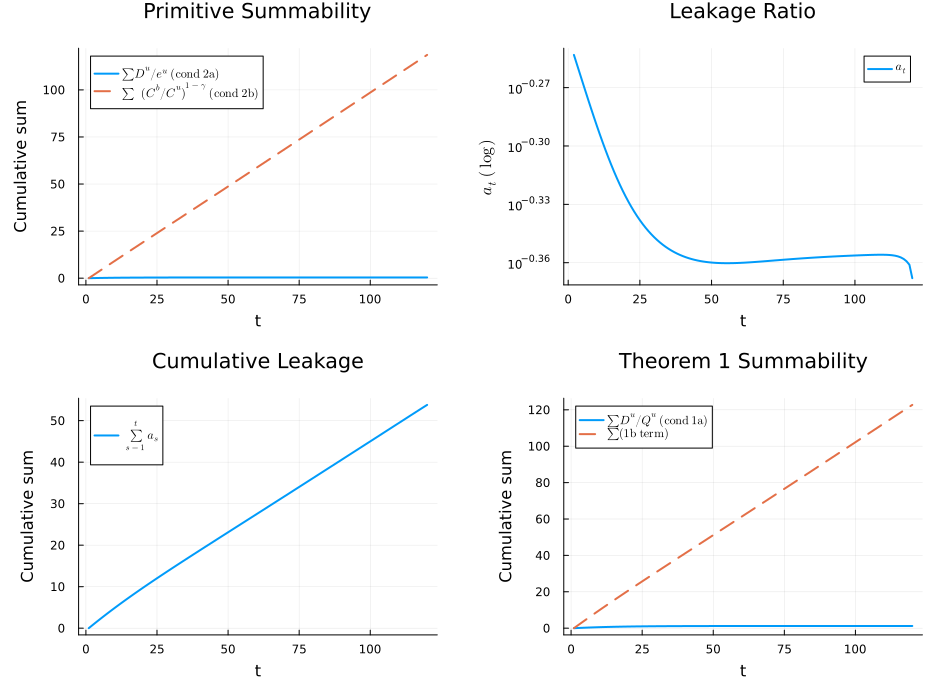

In [13]:
# ── Panel 1: Cumulative Summability Conditions ──
dp1 = plot(tt, diag.sum_dividend_ratio[tt], lw=2, label=L"\sum D^u/e^u\ (\mathrm{cond\ 2a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Primitive Summability")
plot!(dp1, tt, diag.sum_cond_2b[tt], lw=2, ls=:dash,
      label=L"\sum (C^b/C^u)^{1-\gamma}\ (\mathrm{cond\ 2b})")

# ── Panel 2: Individual Leakage Terms ──
dp2 = plot(tt[2:end], diag.a_t[2:end], lw=2, label=L"a_t", yscale=:log10,
           xlabel="t", ylabel=L"a_t\ (\log)",
           title="Leakage Ratio")

# ── Panel 3: Cumulative Leakage ──
dp3 = plot(tt, diag.sum_a_t[tt], lw=2, label=L"\sum_{s=1}^t a_s",
           xlabel="t", ylabel="Cumulative sum",
           title="Cumulative Leakage")

# ── Panel 4: Theorem 1 Conditions (1a) and (1b) ──
sum_1a = cumsum(diag.cond_1a)
sum_1b = cumsum(diag.cond_1b)
dp4 = plot(tt, sum_1a[tt], lw=2, label=L"\sum D^u/Q^u\ (\mathrm{cond\ 1a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Theorem 1 Summability")
plot!(dp4, tt, sum_1b[tt], lw=2, ls=:dash,
      label=L"\sum \mathrm{(1b\ term)}")

plot(dp1, dp2, dp3, dp4, layout=(2,2), size=(950, 700), margin=5Plots.mm)

## 3. Fundamental Value Decomposition

The US stock price decomposes as
$$Q_{US,t} = \underbrace{V_{US,t}}_{\text{fundamental}} + \underbrace{B_{US,t}}_{\text{bubble}}.$$

We compute $V_t$ by backward discounting of dividends using the effective pricing kernel along the u-path, accounting for regime-switching.

In [15]:
# ── Compute fundamental value by backward recursion ──
# V_T = D_T / (R_US - g_b) approximately, or we use the balanced-state to get V_T.
# More precisely: in balanced state b, Q = V (no bubble), so V_T = Q_T^b_hat * e_US[T].

V = zeros(T)
# At terminal date T, if we assume the balanced-state price IS the fundamental:
V[T] = bs[T].Q_US_hat * paths.e_US[T]

# Backward recursion: V_t = E_t[M_{t,t+1} (V_{t+1} + D_{t+1})]
# where the expectation accounts for regime switching
for t in (T-1):-1:1
    s = u_path[t]

    # Under state u at t+1
    V_u_next = V[t+1]    # fundamental on u-path
    D_u_next = paths.D_US[t+1]

    # Under state b at t+1 (switch): Q = V (no bubble)
    V_b_next = bs[t+1].Q_US_hat * paths.e_US[t+1]
    D_b_next = paths.D_US[t+1]  # Assumption 5

    # Compute returns for kernel (using actual Q, not V, since kernel depends on total return)
    Q_US_next_u = u_path[t+1].Q_US
    Q_W_next_u  = u_path[t+1].Q_W
    Q_US_next_b = bs[t+1].Q_US_hat * paths.e_US[t+1]
    Q_W_next_b  = bs[t+1].Q_W_hat  * paths.e_US[t+1]

    ret_u = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_u, Q_W_next_u,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)
    ret_b = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_b, Q_W_next_b,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)

    # Effective kernel for US stock (tex line 432-437)
    # M_eff = M / (1 + Delta),  but Delta cancels in the ratio (tex line 676-677)
    # For the fundamental value computation we need the *effective* pricing kernel
    # The effective kernel M_eff prices the US stock:
    #   Q_US = E[M_eff * (Q_US_{t+1} + D_{t+1})]
    # Since we know Q_US and the expectations structure, we can back out M_eff implicitly.
    # But for computing V, we use the SAME kernel:
    #   V_t = E[M_eff * (V_{t+1} + D_{t+1})]
    # From the Euler equation Q = E[M_eff*(Q+D)], and V = E[M_eff*(V+D)], we get:
    #   Q - V = E[M_eff*(Q_{t+1} - V_{t+1})]  =>  B_t = E[M_eff * B_{t+1}]
    # So we can compute V_t from:
    #   V_t = Q_t - B_t,  where B_t = E[M_eff * B_{t+1}]
    # Or equivalently:
    #   V_t = E[M_eff * (V_{t+1} + D_{t+1})]
    # We compute M_eff from Q_t = E[M_eff*(Q_{t+1}+D_{t+1})].

    # US kernel (normalised portfolio kernel)
    M_u, M_b = us_kernel(ret_u.R_A, ret_b.R_A, p.γ, p.π_persist)

    # Wedge factor (tex lines 156-163)
    phi = p.κ * s.C_y / ((1 - p.β) * s.S) * (s.ω - p.ω̄)
    denom_US = 1 + phi * (1 - s.ω)

    # Effective kernel values
    Meff_u = M_u / denom_US
    Meff_b = M_b / denom_US

    # Scale factor: the raw kernel M = beta/(1-beta) * Cy * Co^{-gamma}/E[Co^{1-gamma}]
    # But our normalised kernel M_{t,t+1} = R_A^{-gamma}/E[R_A^{1-gamma}] is the ratio.
    # The actual SDF used in Q_t = E[SDF * (Q+D)] has the saving rule baked in.
    # From tex eq (US_AP_bond_cost): Q = E[M_eff * (Q+D)] where M_eff = M/(1+Delta)
    # and M = beta/(1-beta) * Cy * Co^{-gamma}/E[Co^{1-gamma}]
    # Using Co = A*R_A and Cy = (1-beta)*e, A = beta*e:
    # M = beta/(1-beta) * (1-beta)*e * (beta*e*R_A)^{-gamma} / (E[(beta*e*R_A)^{1-gamma}])
    #   = beta * e * (beta*e)^{-gamma} * R_A^{-gamma} / ((beta*e)^{1-gamma} * E[R_A^{1-gamma}])
    #   = beta * e^{1-gamma} * beta^{-gamma} / (beta^{1-gamma} * e^{1-gamma}) * R_A^{-gamma}/E[R_A^{1-gamma}]
    #   = beta * beta^{-gamma} / beta^{1-gamma} * M_norm
    #   = beta * beta^{gamma-1} / 1 * M_norm
    #   Wait, let me redo this.
    # M = beta/(1-beta) * Cy * Co^{-gamma} / E[Co^{1-gamma}]
    # Cy = (1-beta)*e, Co = A*R_A = beta*e*R_A
    # M = beta/(1-beta) * (1-beta)*e * (beta*e*R_A)^{-gamma} / E[(beta*e*R_A)^{1-gamma}]
    #   = beta * e * (beta*e)^{-gamma} * R_A^{-gamma} / ((beta*e)^{1-gamma} * E[R_A^{1-gamma}])
    #   = beta * (beta*e)^{-gamma} * e / ((beta*e)^{1-gamma}) * R_A^{-gamma}/E[R_A^{1-gamma}]
    #   = beta * (beta*e)^{-gamma+1-1+gamma} / (1) * R_A^{-gamma}/E[R_A^{1-gamma}]
    #   Hmm, let me just compute (beta*e)^{-gamma} * e / (beta*e)^{1-gamma}
    #   = (beta*e)^{-gamma} * e / (beta*e)^{1-gamma}
    #   = e * (beta*e)^{-gamma - (1-gamma)}
    #   = e * (beta*e)^{-1}
    #   = e / (beta*e) = 1/beta
    # So M = beta * (1/beta) * M_norm = M_norm
    # Great! So M = M_norm = R_A^{-gamma}/E[R_A^{1-gamma}]

    # Therefore M_eff = M_norm / (1+Delta) and
    # V_t = E[M_eff * (V_{t+1} + D_{t+1})]
    #      = pi * Meff_u * (V_u_next + D_u_next) + (1-pi) * Meff_b * (V_b_next + D_b_next)

    V[t] = p.π_persist * Meff_u * (V_u_next + D_u_next) +
           (1 - p.π_persist) * Meff_b * (V_b_next + D_b_next)
end

B = Q_US_vec .- V
bubble_share = B ./ Q_US_vec

@printf("At t=1:  Q_US = %.4e,  V = %.4e,  B = %.4e,  B/Q = %.4f\n",
        Q_US_vec[1], V[1], B[1], bubble_share[1])

At t=1:  Q_US = 5.0033e-01,  V = 4.3654e-01,  B = 6.3784e-02,  B/Q = 0.1275


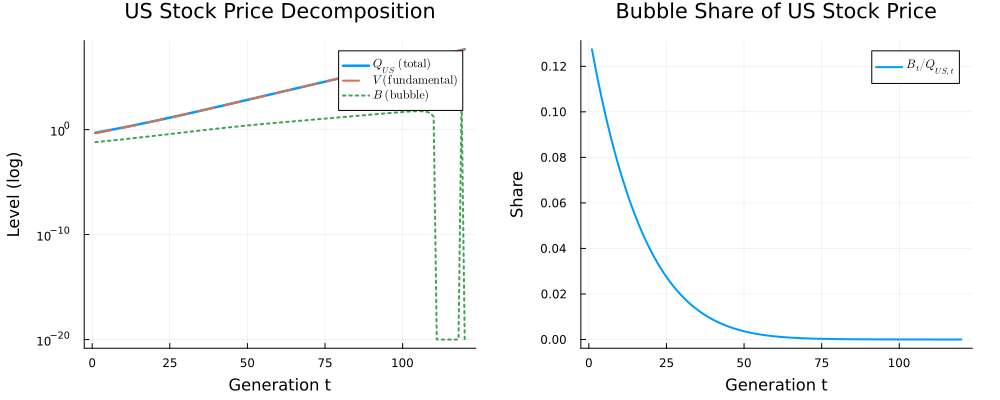

In [16]:
# ── Price Decomposition Plot ──
fp1 = plot(tt, Q_US_vec, label=L"Q_{US}\ (\mathrm{total})", lw=2.5, yscale=:log10,
           xlabel="Generation t", ylabel="Level (log)",
           title="US Stock Price Decomposition")
plot!(fp1, tt, V, label=L"V\ (\mathrm{fundamental})", lw=2, ls=:dash)
plot!(fp1, tt, max.(B, 1e-20), label=L"B\ (\mathrm{bubble})", lw=2, ls=:dot)

fp2 = plot(tt, bubble_share, lw=2, label=L"B_t / Q_{US,t}",
           xlabel="Generation t", ylabel="Share",
           title="Bubble Share of US Stock Price")

plot(fp1, fp2, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

## 4. Detailed Leakage Analysis

From the proof of Theorem 1 (tex lines 688–698), the leakage ratio decomposes as:

$$a_t = \underbrace{\frac{D_t^u}{Q_t^u}}_{\text{dividend leakage}} + \underbrace{\frac{1-\pi}{\pi}\left(\frac{C_t^u}{C_t^b}\right)^{\gamma}\frac{Q_t^b + D_t^b}{Q_t^u}}_{\text{switch leakage}}$$

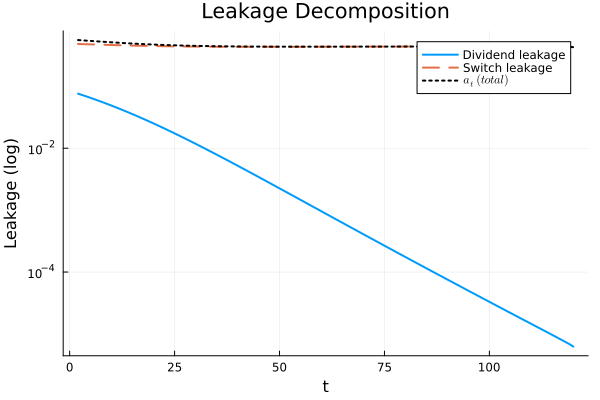

In [17]:
# ── Decompose leakage into dividend and switch components ──
div_leak   = diag.cond_1a       # D^u/Q^u
switch_leak = diag.a_t .- diag.cond_1a

dp_leak = plot(tt[2:end], div_leak[2:end], lw=2, label="Dividend leakage",
               yscale=:log10, xlabel="t", ylabel="Leakage (log)",
               title="Leakage Decomposition")
plot!(dp_leak, tt[2:end], switch_leak[2:end], lw=2, ls=:dash, label="Switch leakage")
plot!(dp_leak, tt[2:end], diag.a_t[2:end], lw=2, ls=:dot, lc=:black, label=L"a_t\ (total)")

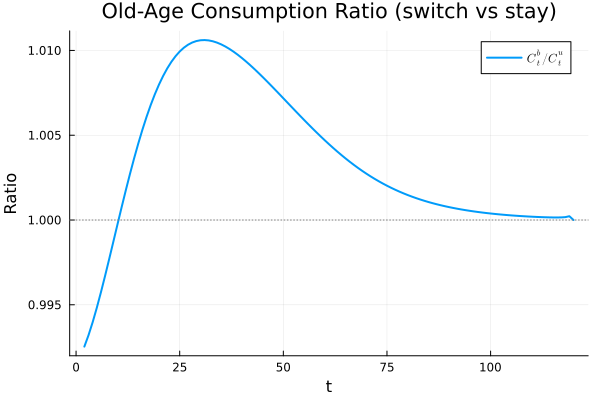

In [18]:
# ── Consumption ratio across regimes ──
# C^b_t / C^u_t = R_A^b / R_A^u  at date t
consump_ratio = zeros(T)
for t in 2:T
    s_prev = u_path[t-1]

    ret_u = compute_returns(s_prev.Q_US, s_prev.Q_W,
                u_path[t].Q_US, u_path[t].Q_W,
                paths.D_US[t], paths.D_W[t],
                s_prev.ω, s_prev.ω_star,
                s_prev.θ, s_prev.θ_US_star, s_prev.R_f)

    Q_US_b = bs[t].Q_US_hat * paths.e_US[t]
    Q_W_b  = bs[t].Q_W_hat  * paths.e_US[t]
    ret_b = compute_returns(s_prev.Q_US, s_prev.Q_W,
                Q_US_b, Q_W_b,
                paths.D_US[t], paths.D_W[t],
                s_prev.ω, s_prev.ω_star,
                s_prev.θ, s_prev.θ_US_star, s_prev.R_f)

    consump_ratio[t] = ret_b.R_A / ret_u.R_A
end

cr_plot = plot(tt[2:end], consump_ratio[2:end], lw=2,
              label=L"C^b_t / C^u_t",
              xlabel="t", ylabel="Ratio",
              title="Old-Age Consumption Ratio (switch vs stay)")
hline!(cr_plot, [1.0], ls=:dot, lc=:gray, label="")

## Summary

- **Condition (2a)** (dividend summability): converges because $g_{D,u} < g_{e,u}$.
- **Condition (2b)** (consumption ratio summability): its convergence depends on how $R_A^b/R_A^u$ behaves over time.
- The **leakage ratio** $a_t$ decays toward zero, and its sum $\sum a_t$ converges to a finite limit $\Rightarrow$ **bubble exists**.
- The **bubble share** $B_t/Q_{US,t}$ shows the fraction of the US stock price attributable to the bubble.

**Next**: Notebook 05 performs comparative statics over key parameters.